In [22]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
import time

from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, classification_report, roc_auc_score

from sklearn.ensemble import GradientBoostingClassifier
from sklearn.svm import SVC
from sklearn.neighbors import KNeighborsClassifier
from sklearn.neural_network import MLPClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.model_selection import GridSearchCV

sns.set_theme()

   # Dataset #1: Bank Marketing Data Set
   
   The Bank Marketing Data Set from the UCI Machine Learning Repository is used for this project. The dataset contains information about the success of a bank's marketing campaign for a specific product. The goal is to predict whether a client will subscribe to a term deposit. The dataset can be found here: https://archive.ics.uci.edu/ml/datasets/Bank+Marketing
   
   
   ## Input variables:
   ### Bank client data:
   
   1) age (numeric)
   2) job : type of job (categorical: "admin.","unknown","unemployed","management","housemaid","entrepreneur","student",
                                       "blue-collar","self-employed","retired","technician","services") 
   3) marital : marital status (categorical: "married","divorced","single"; note: "divorced" means divorced or widowed)
   4) education (categorical: "unknown","secondary","primary","tertiary")
   5) default: has credit in default? (binary: "yes","no")
   6) balance: average yearly balance, in euros (numeric) 
   7) housing: has housing loan? (binary: "yes","no")
   8) loan: has personal loan? (binary: "yes","no")

   ### Related with the last contact of the current campaign:

   9) contact: contact communication type (categorical: "unknown","telephone","cellular") 
  10) day: last contact day of the month (numeric)
  11) month: last contact month of year (categorical: "jan", "feb", "mar", ..., "nov", "dec")
  12) duration: last contact duration, in seconds (numeric)

   ### Other attributes:

  13) campaign: number of contacts performed during this campaign and for this client (numeric, includes last contact)
  14) pdays: number of days that passed by after the client was last contacted from a previous campaign (numeric, -1 means client was not previously contacted)
  15) previous: number of contacts performed before this campaign and for this client (numeric)
  16) poutcome: outcome of the previous marketing campaign (categorical: "unknown","other","failure","success")

  ## Output variable (desired target):
  17) y - has the client subscribed a term deposit? (binary: "yes","no")


In [2]:
df_bank = pd.read_csv('bank-full.csv', sep=';')
binary_map = {'yes': 1, 'no': 0}
df_bank['y'] = df_bank['y'].map(binary_map)
df_bank.head()

,age,job,marital,education,default,balance,housing,loan,contact,day,month,duration,campaign,pdays,previous,poutcome,y
0,58,management,married,tertiary,no,2143,yes,no,unknown,5,may,261,1,-1,0,unknown,0
1,44,technician,single,secondary,no,29,yes,no,unknown,5,may,151,1,-1,0,unknown,0
2,33,entrepreneur,married,secondary,no,2,yes,yes,unknown,5,may,76,1,-1,0,unknown,0
3,47,blue-collar,married,unknown,no,1506,yes,no,unknown,5,may,92,1,-1,0,unknown,0
4,33,unknown,single,unknown,no,1,no,no,unknown,5,may,198,1,-1,0,unknown,0


In [3]:
df_bank['y'].value_counts()/df_bank.shape[0]

y
0    0.883015
1    0.116985
Name: count, dtype: float64

In [4]:
df_bank.isna().sum()

age          0
job          0
marital      0
education    0
default      0
balance      0
housing      0
loan         0
contact      0
day          0
month        0
duration     0
campaign     0
pdays        0
previous     0
poutcome     0
y            0
dtype: int64

In [5]:
df_bank.describe(include='all')

,age,job,marital,education,default,balance,housing,loan,contact,day,month,duration,campaign,pdays,previous,poutcome,y
count,45211.000000,45211,45211,45211,45211,45211.000000,45211,45211,45211,45211.000000,45211,45211.000000,45211.000000,45211.000000,45211.000000,45211,45211.000000
unique,NaN,12,3,4,2,NaN,2,2,3,NaN,12,NaN,NaN,NaN,NaN,4,NaN
top,NaN,blue-collar,married,secondary,no,NaN,yes,no,cellular,NaN,may,NaN,NaN,NaN,NaN,unknown,NaN
freq,NaN,9732,27214,23202,44396,NaN,25130,37967,29285,NaN,13766,NaN,NaN,NaN,NaN,36959,NaN
mean,40.936210,NaN,NaN,NaN,NaN,1362.272058,NaN,NaN,NaN,15.806419,NaN,258.163080,2.763841,40.197828,0.580323,NaN,0.116985
std,10.618762,NaN,NaN,NaN,NaN,3044.765829,NaN,NaN,NaN,8.322476,NaN,257.527812,3.098021,100.128746,2.303441,NaN,0.321406
min,18.000000,NaN,NaN,NaN,NaN,-8019.000000,NaN,NaN,NaN,1.000000,NaN,0.000000,1.000000,-1.000000,0.000000,NaN,0.000000
25%,33.000000,NaN,NaN,NaN,NaN,72.000000,NaN,NaN,NaN,8.000000,NaN,103.000000,1.000000,-1.000000,0.000000,NaN,0.000000
50%,39.000000,NaN,NaN,NaN,NaN,448.000000,NaN,NaN,NaN,16.000000,NaN,180.000000,2.000000,-1.000000,0.000000,NaN,0.000000
75%,48.000000,NaN,NaN,NaN,NaN,1428.000000,NaN,NaN,NaN,21.000000,NaN,319.000000,3.000000,-1.000000,0.000000,NaN,0.000000


In [6]:
cols_cat_binary = ['default', 'housing', 'loan']
for col in cols_cat_binary:
    df_bank[col] = df_bank[col].map(binary_map)

cols_cat_nom = ['job', 'marital', 'contact', 'poutcome']
df_bank = pd.get_dummies(df_bank, columns=cols_cat_nom, drop_first=True)

cat_ord_map = {'education': {'unknown': 0, 'primary': 1, 'secondary': 2, 'tertiary': 3},
               'month': {'jan': 1, 'feb': 2, 'mar': 3, 'apr': 4, 'may': 5,
                         'jun': 6, 'jul': 7, 'aug': 8, 'sep': 9, 'oct': 10,
                         'nov': 11, 'dec': 12}}

df_bank = df_bank.replace(cat_ord_map)

# y as the last column
df_bank = df_bank[[col for col in df_bank.columns if col != 'y'] + ['y']]

df_bank.head()

,age,education,default,balance,housing,loan,day,month,duration,campaign,...,job_unemployed,job_unknown,marital_married,marital_single,contact_telephone,contact_unknown,poutcome_other,poutcome_success,poutcome_unknown,y
0,58,3,0,2143,1,0,5,5,261,1,...,False,False,True,False,False,True,False,False,True,0
1,44,2,0,29,1,0,5,5,151,1,...,False,False,False,True,False,True,False,False,True,0
2,33,2,0,2,1,1,5,5,76,1,...,False,False,True,False,False,True,False,False,True,0
3,47,0,0,1506,1,0,5,5,92,1,...,False,False,True,False,False,True,False,False,True,0
4,33,0,0,1,0,0,5,5,198,1,...,False,True,False,True,False,True,False,False,True,0


In [7]:
df_bank.describe(include='all')

,age,education,default,balance,housing,loan,day,month,duration,campaign,...,job_unemployed,job_unknown,marital_married,marital_single,contact_telephone,contact_unknown,poutcome_other,poutcome_success,poutcome_unknown,y
count,45211.000000,45211.000000,45211.000000,45211.000000,45211.000000,45211.000000,45211.000000,45211.000000,45211.000000,45211.000000,...,45211,45211,45211,45211,45211,45211,45211,45211,45211,45211.000000
unique,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,2,2,2,2,2,2,2,2,2,NaN
top,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,False,False,True,False,False,False,False,False,True,NaN
freq,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,43908,44923,27214,32421,42305,32191,43371,43700,36959,NaN
mean,40.936210,2.060516,0.018027,1362.272058,0.555838,0.160226,15.806419,6.144655,258.163080,2.763841,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.116985
std,10.618762,0.778704,0.133049,3044.765829,0.496878,0.366820,8.322476,2.408034,257.527812,3.098021,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.321406
min,18.000000,0.000000,0.000000,-8019.000000,0.000000,0.000000,1.000000,1.000000,0.000000,1.000000,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.000000
25%,33.000000,2.000000,0.000000,72.000000,0.000000,0.000000,8.000000,5.000000,103.000000,1.000000,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.000000
50%,39.000000,2.000000,0.000000,448.000000,1.000000,0.000000,16.000000,6.000000,180.000000,2.000000,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.000000
75%,48.000000,3.000000,0.000000,1428.000000,1.000000,0.000000,21.000000,8.000000,319.000000,3.000000,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.000000


In [8]:
models = {'Decision Tree': DecisionTreeClassifier(),
          'Gradient Boosting': GradientBoostingClassifier(),
          #'SVM': SVC(),
          'KNN': KNeighborsClassifier(),
          'Neural Network': MLPClassifier()}

hyperparam_search = {'Decision Tree': {'max_depth': [2, 5, 7, 10, 15, 20, None],
                                       'criterion': ['gini']},
                     'Gradient Boosting': {'learning_rate': [0.01, 0.1, 1],
                                             'max_depth': [2, 5, 7, 10, 15, 20, None]},
                     'KNN': {'n_neighbors': [1, 3, 5, 7]},
                     'Neural Network': {'hidden_layer_sizes': [(50,), (100,), (7, 7), (10, 10), (50, 50)],
                                        'alpha': [0.001, 0.1, 1],
                                        'activation': ['relu'],
                                        'solver': ['adam']}}

sample_sizes = [0.5, 0.01, 0.1, 1.0]

def eval_models_on_df(df, df_name, target, models, hyperparams,
                      sample_sizes, cv_folds=3):
    
    print('Evaluating models on {} dataset'.format(df_name))
    print('Target variable: {}'.format(target))
    print('{} sample sizes, cross-validation with {} folds.'.format(len(sample_sizes), cv_folds))
    
    best_hyperparams = {}
    results = []
    cv_results = []
    
    for iter_sample, sample in enumerate(sample_sizes):
        print('Sample fraction: {}'.format(sample))
        # stratified sampling on target variable
        df_sample = (df.groupby(target, group_keys=False)
                       .apply(lambda x: x.sample(frac=sample, random_state=42)))
        
        X, y = df_sample.drop(target, axis=1), df_sample[target]
        
        # split into train and test sets
        X_train, X_test, y_train, y_test = train_test_split(X, y, stratify=y, random_state=42)
        
        for model_name, model in models.items():
            print('Model: {}'.format(model_name))
            
            # will only do hyperparameter tuning for the first sample size
            if iter_sample == 0:
                print('Hyperparameter tuning...')
                grid = GridSearchCV(model, hyperparams[model_name], 
                                    scoring='roc_auc', cv=cv_folds, n_jobs=-1)
                grid.fit(X_train, y_train)
                best_hyperparams[model_name] = grid.best_params_
                print('Best hyperparameters: {}'.format(grid.best_params_))
                
                
                cv_res = pd.DataFrame(grid.cv_results_)
                cv_res['model'] = model_name
                cv_results.append(cv_res)
                

            # train model with best hyperparameters
            model.set_params(**best_hyperparams[model_name])
            start = time.time()
            model.fit(X_train, y_train)
            end = time.time()
            train_time = end - start
            y_pred = model.predict(X_test)
            
            # calculate train metrics
            train_rep = classification_report(y_train, model.predict(X_train), output_dict=True)['macro avg']
            train_precision, train_recall, train_f1 = train_rep['precision'], train_rep['recall'], train_rep['f1-score']
            train_acc = accuracy_score(y_train, model.predict(X_train))
            train_auc = roc_auc_score(y_train, model.predict_proba(X_train)[:, 1])

            # calculate test metrics
            test_rep = classification_report(y_test, y_pred, output_dict=True)['macro avg']
            test_precision, test_recall, test_f1 = test_rep['precision'], test_rep['recall'], test_rep['f1-score']
            test_acc = accuracy_score(y_test, y_pred)
            test_auc = roc_auc_score(y_test, model.predict_proba(X_test)[:, 1])
            
            scores = {'dataset': df_name,
                    'sample_size': sample,
                    'model': model_name,
                    'train_time': train_time,
                    'train_precision': train_precision,
                    'train_recall': train_recall,
                    'train_f1': train_f1,
                    'train_acc': train_acc,
                    'train_auc': train_auc,
                    'test_precision': test_precision,
                    'test_recall': test_recall,
                    'test_f1': test_f1,
                    'test_acc': test_acc,
                    'test_auc': test_auc}
            
            results.append(scores)     
            
    df_results = pd.DataFrame(results)
    df_cv_results = pd.concat(cv_results)
    # save results to parquet
    timestamp = time.strftime('%Y%m%d-%H%M%S')
    df_results.to_parquet('results_{}-{}.parquet'.format(df_name, timestamp))
    df_cv_results.to_parquet('cv_results_{}-{}.parquet'.format(df_name, timestamp))
    return df_results, df_cv_results
           
        
        

# Dataset #2: Wine Quality

The Wine Quality Data Set from the UCI Machine Learning Repository is used for this project. The dataset contains information about the quality of red and white variants of the Portuguese "Vinho Verde" wine. The goal is to predict the quality of the wine. The dataset can be found here: https://archive.ics.uci.edu/ml/datasets/Wine+Quality

## Input variables (based on physicochemical tests):

1) is_red (red or white)
2) fixed acidity
3) volatile acidity
4) citric acid
5) residual sugar
6) chlorides
7) free sulfur dioxide
8) total sulfur dioxide
9) density
10) pH
11) sulphates
12) alcohol

## Output variable (based on sensory data):
13) quality (score between 0 and 10)


In [9]:
df_wine_red = pd.read_csv('winequality-red.csv', sep=';')
df_wine_white = pd.read_csv('winequality-white.csv', sep=';')

df_wine_red['is_red'] = 1
df_wine_white['is_red'] = 0

df_wine = pd.concat([df_wine_red, df_wine_white], axis=0).reset_index(drop=True)
df_wine['quality'] = df_wine['quality'].map(lambda x: 1 if x >= 7 else 0)
df_wine.head()

,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol,quality,is_red
0,7.4,0.70,0.00,1.9,0.076,11.0,34.0,0.9978,3.51,0.56,9.4,0,1
1,7.8,0.88,0.00,2.6,0.098,25.0,67.0,0.9968,3.20,0.68,9.8,0,1
2,7.8,0.76,0.04,2.3,0.092,15.0,54.0,0.9970,3.26,0.65,9.8,0,1
3,11.2,0.28,0.56,1.9,0.075,17.0,60.0,0.9980,3.16,0.58,9.8,0,1
4,7.4,0.70,0.00,1.9,0.076,11.0,34.0,0.9978,3.51,0.56,9.4,0,1


In [10]:
df_wine['quality'].value_counts()/df_wine.shape[0]

quality
0    0.803448
1    0.196552
Name: count, dtype: float64

In [36]:
#df_results_bank, df_cv_bank = eval_models_on_df(df_bank, 'bank', 'y', models, hyperparam_search, sample_sizes, 3)
#df_results_wine, df_cv_wine = eval_models_on_df(df_wine, 'wine', 'quality', models, hyperparam_search, sample_sizes, 3)

df_results_bank = pd.read_parquet('results_bank-20230924-221404.parquet')
df_cv_bank = pd.read_parquet('cv_results_bank-20230924-221404.parquet')
df_cv_bank['dataset'] = 'bank'

df_results_wine = pd.read_parquet('results_wine-20230924-221438.parquet')
df_cv_wine = pd.read_parquet('cv_results_wine-20230924-221438.parquet')
df_cv_wine['dataset'] = 'wine'


In [38]:
svm_dict = {'SVM': {'C': [0.01, 0.1, 0.5],
                    'kernel': ['rbf', 'sigmoid'],
                    'gamma': ['scale'],
                    'tol': [0.001],
                    'probability': [True]}}
model_svm = {'SVM': SVC()}


from sklearn.preprocessing import StandardScaler

df_wine_svm = df_wine.copy()
df_wine_svm.drop('quality', axis=1, inplace=True)
df_wine_svm = pd.DataFrame(StandardScaler().fit_transform(df_wine_svm), columns=df_wine_svm.columns)
df_wine_svm['quality'] = df_wine['quality']


#df_results_wine_svm, df_cv_wine_svm = eval_models_on_df(df_wine_svm, 'wine', 'quality', model_svm, svm_dict, sample_sizes, 3)

df_bank_svm = df_bank.copy()
df_bank_svm.drop('y', axis=1, inplace=True)
df_bank_svm = pd.DataFrame(StandardScaler().fit_transform(df_bank_svm), columns=df_bank_svm.columns)
df_bank_svm['y'] = df_bank['y']

df_bank_svm = df_bank_svm.sample(frac=0.1, random_state=42)

#df_results_bank_svm, df_cv_bank_svm = eval_models_on_df(df_bank_svm, 'bank', 'y', model_svm, svm_dict, sample_sizes, 3)

df_results_wine_svm = pd.read_parquet('results_wine-20230924-222018.parquet')
df_cv_wine_svm = pd.read_parquet('cv_results_wine-20230924-222018.parquet')
df_cv_wine_svm['dataset'] = 'wine'

df_results_bank_svm = pd.read_parquet('results_bank-20230924-222023.parquet')
df_cv_bank_svm = pd.read_parquet('cv_results_bank-20230924-222023.parquet')
df_cv_bank_svm['dataset'] = 'bank'

In [39]:
df_results = pd.concat([df_results_bank, df_results_wine, df_results_wine_svm, df_results_bank_svm], axis=0)
df_results.head()

,dataset,sample_size,model,train_time,train_precision,train_recall,train_f1,train_acc,train_auc,test_precision,test_recall,test_f1,test_acc,test_auc
0,bank,0.50,Decision Tree,0.038596,0.794902,0.670594,0.710000,0.904619,0.831554,0.780379,0.655605,0.693389,0.900566,0.826316
1,bank,0.50,Gradient Boosting,3.345576,0.892438,0.779406,0.823219,0.937238,0.960663,0.783577,0.694659,0.727483,0.904636,0.924184
2,bank,0.50,KNN,0.009939,0.802147,0.658716,0.700270,0.904501,0.922150,0.722895,0.615279,0.644478,0.887297,0.779481
3,bank,0.50,Neural Network,2.650124,0.732517,0.656909,0.683955,0.890108,0.868491,0.758146,0.663245,0.695509,0.896674,0.867304
4,bank,0.01,Decision Tree,0.004079,0.921420,0.855811,0.884864,0.955752,0.955560,0.649074,0.561923,0.577457,0.876106,0.775769


In [41]:
df_cvs = pd.concat([df_cv_bank, df_cv_wine, df_cv_wine_svm, df_cv_bank_svm], axis=0)
df_cvs.head()

,mean_fit_time,std_fit_time,mean_score_time,std_score_time,param_criterion,param_max_depth,params,split0_test_score,split1_test_score,split2_test_score,...,param_activation,param_alpha,param_hidden_layer_sizes,param_solver,dataset,param_C,param_gamma,param_kernel,param_probability,param_tol
0,0.040355,0.008408,0.027413,0.014899,gini,2.0,"{'activation': None, 'alpha': None, 'criterion...",0.738286,0.763965,0.727405,...,None,NaN,None,None,bank,NaN,NaN,NaN,NaN,NaN
1,0.087052,0.004638,0.021345,0.003385,gini,5.0,"{'activation': None, 'alpha': None, 'criterion...",0.829702,0.855212,0.859605,...,None,NaN,None,None,bank,NaN,NaN,NaN,NaN,NaN
2,0.120881,0.004150,0.017279,0.003569,gini,7.0,"{'activation': None, 'alpha': None, 'criterion...",0.802916,0.847955,0.859389,...,None,NaN,None,None,bank,NaN,NaN,NaN,NaN,NaN
3,0.165353,0.007223,0.021101,0.005854,gini,10.0,"{'activation': None, 'alpha': None, 'criterion...",0.759920,0.802357,0.779428,...,None,NaN,None,None,bank,NaN,NaN,NaN,NaN,NaN
4,0.143922,0.016970,0.011572,0.000612,gini,15.0,"{'activation': None, 'alpha': None, 'criterion...",0.636228,0.721714,0.633188,...,None,NaN,None,None,bank,NaN,NaN,NaN,NaN,NaN


In [42]:
df_results['diff_auc'] = df_results['train_auc'] - df_results['test_auc']
df_results['diff_acc'] = df_results['train_acc'] - df_results['test_acc']
df_results['diff_f1'] = df_results['train_f1'] - df_results['test_f1']
df_results['diff_precision'] = df_results['train_precision'] - df_results['test_precision']
df_results['diff_recall'] = df_results['train_recall'] - df_results['test_recall']



In [43]:
df_results.head()

,dataset,sample_size,model,train_time,train_precision,train_recall,train_f1,train_acc,train_auc,test_precision,test_recall,test_f1,test_acc,test_auc,diff_auc,diff_acc,diff_f1,diff_precision,diff_recall
0,bank,0.50,Decision Tree,0.038596,0.794902,0.670594,0.710000,0.904619,0.831554,0.780379,0.655605,0.693389,0.900566,0.826316,0.005238,0.004052,0.016611,0.014523,0.014989
1,bank,0.50,Gradient Boosting,3.345576,0.892438,0.779406,0.823219,0.937238,0.960663,0.783577,0.694659,0.727483,0.904636,0.924184,0.036479,0.032603,0.095736,0.108862,0.084746
2,bank,0.50,KNN,0.009939,0.802147,0.658716,0.700270,0.904501,0.922150,0.722895,0.615279,0.644478,0.887297,0.779481,0.142669,0.017204,0.055792,0.079253,0.043436
3,bank,0.50,Neural Network,2.650124,0.732517,0.656909,0.683955,0.890108,0.868491,0.758146,0.663245,0.695509,0.896674,0.867304,0.001187,-0.006566,-0.011554,-0.025629,-0.006336
4,bank,0.01,Decision Tree,0.004079,0.921420,0.855811,0.884864,0.955752,0.955560,0.649074,0.561923,0.577457,0.876106,0.775769,0.179791,0.079646,0.307406,0.272346,0.293888


/Users/lfelipe/opt/anaconda3/envs/ml_gatech/lib/python3.11/site-packages/seaborn/_oldcore.py:1498: FutureWarning: is_categorical_dtype is deprecated and will be removed in a future version. Use isinstance(dtype, CategoricalDtype) instead
  if pd.api.types.is_categorical_dtype(vector):
/Users/lfelipe/opt/anaconda3/envs/ml_gatech/lib/python3.11/site-packages/seaborn/_oldcore.py:1498: FutureWarning: is_categorical_dtype is deprecated and will be removed in a future version. Use isinstance(dtype, CategoricalDtype) instead
  if pd.api.types.is_categorical_dtype(vector):
/Users/lfelipe/opt/anaconda3/envs/ml_gatech/lib/python3.11/site-packages/seaborn/_oldcore.py:1498: FutureWarning: is_categorical_dtype is deprecated and will be removed in a future version. Use isinstance(dtype, CategoricalDtype) instead
  if pd.api.types.is_categorical_dtype(vector):
/Users/lfelipe/opt/anaconda3/envs/ml_gatech/lib/python3.11/site-packages/seaborn/_oldcore.py:1498: FutureWarning: is_categorical_dtype is depr

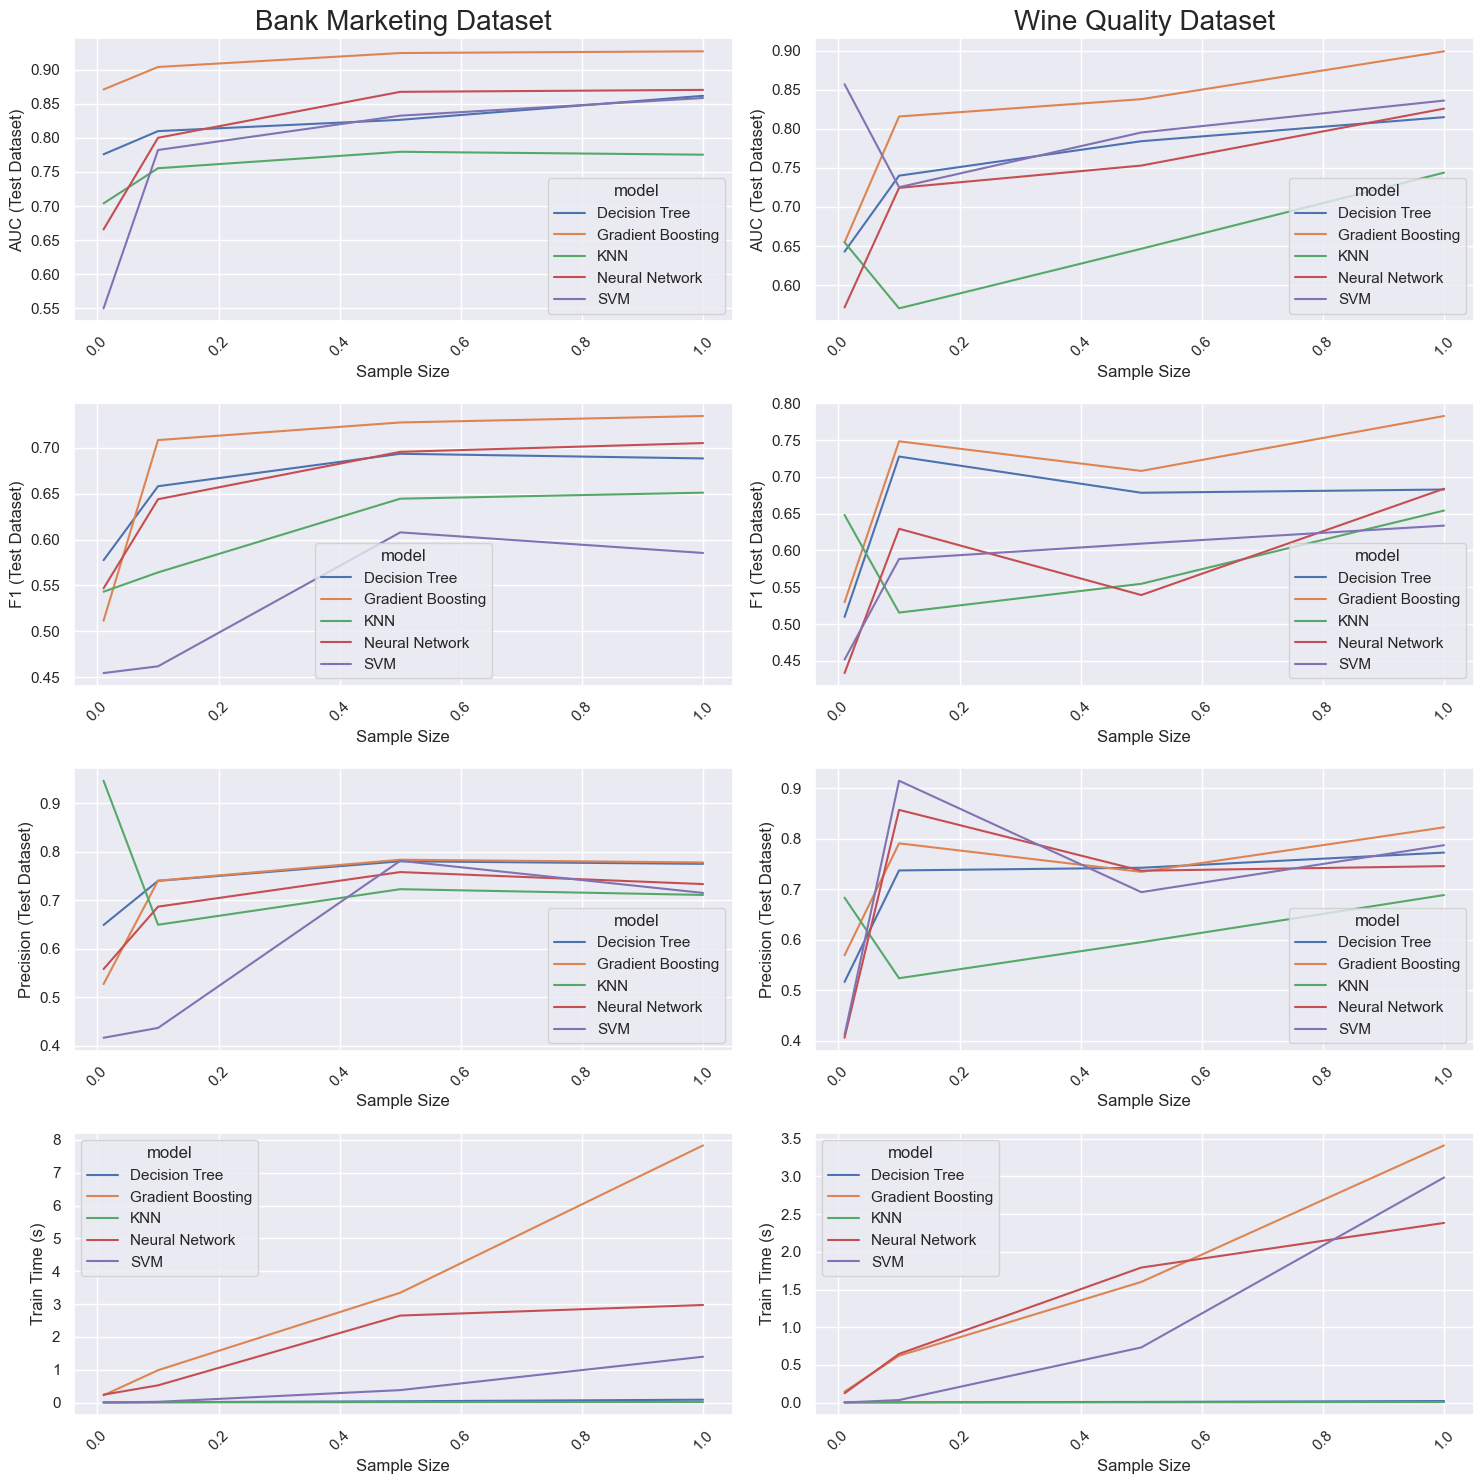

In [81]:
fig, ax = plt.subplots(4, 2, figsize=(15, 15))

metric_labels = ['AUC (Test Dataset)', 'F1 (Test Dataset)', 'Precision (Test Dataset)', 'Train Time (s)']
metrics = ['test_auc', 'test_f1', 'test_precision', 'train_time']
titles = ['Bank Marketing Dataset', 'Wine Quality Dataset']
for i, dataset in enumerate(['bank', 'wine']):
    ax[0, i].set_title(titles[i])
    ax[0, i].title.set_fontsize(20)
    for j, metric in enumerate(metrics):
        sns.lineplot(x='sample_size', y=metric, hue='model', 
                     data=df_results[df_results['dataset'] == dataset], ax=ax[j, i])
        ax[j, i].set_xlabel('Sample Size')
        ax[j, i].set_ylabel(metric_labels[j])
        
        ax[j, i].set_xticklabels(ax[j, i].get_xticklabels(), rotation=45)
        
plt.tight_layout()
sns.set_theme()
plt.savefig('models_sample_size.png', dpi=300)

In [45]:
df_cvs.columns

Index(['mean_fit_time', 'std_fit_time', 'mean_score_time', 'std_score_time',
       'param_criterion', 'param_max_depth', 'params', 'split0_test_score',
       'split1_test_score', 'split2_test_score', 'mean_test_score',
       'std_test_score', 'rank_test_score', 'model', 'param_learning_rate',
       'param_n_neighbors', 'param_activation', 'param_alpha',
       'param_hidden_layer_sizes', 'param_solver', 'dataset', 'param_C',
       'param_gamma', 'param_kernel', 'param_probability', 'param_tol'],
      dtype='object')

In [48]:
df_cvs_ = df_cvs[['dataset', 'model', 'params', 'mean_fit_time', 'mean_test_score']]

In [55]:
df_cvs_model['hidden_layer_sizes'] = df_cvs_model['hidden_layer_sizes'].astype('str')

/var/folders/69/h5r07b216t556dhx6vq0dp880000gp/T/ipykernel_13803/1341163470.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_cvs_model['hidden_layer_sizes'] = df_cvs_model['hidden_layer_sizes'].astype('str')


In [56]:
sns.lineplot(x=params[model], y='mean_test_score', 
                     data=df_cvs_model, ax=ax[j, i])

/Users/lfelipe/opt/anaconda3/envs/ml_gatech/lib/python3.11/site-packages/seaborn/_oldcore.py:1498: FutureWarning: is_categorical_dtype is deprecated and will be removed in a future version. Use isinstance(dtype, CategoricalDtype) instead
  if pd.api.types.is_categorical_dtype(vector):
/Users/lfelipe/opt/anaconda3/envs/ml_gatech/lib/python3.11/site-packages/seaborn/_oldcore.py:1498: FutureWarning: is_categorical_dtype is deprecated and will be removed in a future version. Use isinstance(dtype, CategoricalDtype) instead
  if pd.api.types.is_categorical_dtype(vector):
/Users/lfelipe/opt/anaconda3/envs/ml_gatech/lib/python3.11/site-packages/seaborn/_oldcore.py:1498: FutureWarning: is_categorical_dtype is deprecated and will be removed in a future version. Use isinstance(dtype, CategoricalDtype) instead
  if pd.api.types.is_categorical_dtype(vector):
/Users/lfelipe/opt/anaconda3/envs/ml_gatech/lib/python3.11/site-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is depr

<Axes: xlabel='hidden_layer_sizes', ylabel='mean_test_score'>

In [60]:
df_cvs_model

,dataset,model,params,mean_fit_time,mean_test_score,hidden_layer_sizes
0,wine,Neural Network,"{'activation': 'relu', 'alpha': 0.001, 'criter...",2.589069,0.792848,[50]
1,wine,Neural Network,"{'activation': 'relu', 'alpha': 0.001, 'criter...",2.462192,0.793245,[100]
2,wine,Neural Network,"{'activation': 'relu', 'alpha': 0.001, 'criter...",2.971657,0.689554,[7 7]
3,wine,Neural Network,"{'activation': 'relu', 'alpha': 0.001, 'criter...",3.027448,0.746316,[10 10]
4,wine,Neural Network,"{'activation': 'relu', 'alpha': 0.001, 'criter...",2.974820,0.780512,[50 50]
5,wine,Neural Network,"{'activation': 'relu', 'alpha': 0.1, 'criterio...",1.966369,0.775517,[50]
6,wine,Neural Network,"{'activation': 'relu', 'alpha': 0.1, 'criterio...",1.875035,0.786825,[100]
7,wine,Neural Network,"{'activation': 'relu', 'alpha': 0.1, 'criterio...",3.083436,0.723335,[7 7]
8,wine,Neural Network,"{'activation': 'relu', 'alpha': 0.1, 'criterio...",2.558959,0.740255,[10 10]
9,wine,Neural Network,"{'activation': 'relu', 'alpha': 0.1, 'criterio...",2.190489,0.782067,[50 50]


In [62]:
df_cvs.columns

Index(['mean_fit_time', 'std_fit_time', 'mean_score_time', 'std_score_time',
       'param_criterion', 'param_max_depth', 'params', 'split0_test_score',
       'split1_test_score', 'split2_test_score', 'mean_test_score',
       'std_test_score', 'rank_test_score', 'model', 'param_learning_rate',
       'param_n_neighbors', 'param_activation', 'param_alpha',
       'param_hidden_layer_sizes', 'param_solver', 'dataset', 'param_C',
       'param_gamma', 'param_kernel', 'param_probability', 'param_tol'],
      dtype='object')

In [63]:
df_cvs

,mean_fit_time,std_fit_time,mean_score_time,std_score_time,param_criterion,param_max_depth,params,split0_test_score,split1_test_score,split2_test_score,...,param_activation,param_alpha,param_hidden_layer_sizes,param_solver,dataset,param_C,param_gamma,param_kernel,param_probability,param_tol
0,0.040355,0.008408,0.027413,0.014899,gini,2.0,"{'activation': None, 'alpha': None, 'criterion...",0.738286,0.763965,0.727405,...,None,NaN,None,None,bank,NaN,NaN,NaN,NaN,NaN
1,0.087052,0.004638,0.021345,0.003385,gini,5.0,"{'activation': None, 'alpha': None, 'criterion...",0.829702,0.855212,0.859605,...,None,NaN,None,None,bank,NaN,NaN,NaN,NaN,NaN
2,0.120881,0.004150,0.017279,0.003569,gini,7.0,"{'activation': None, 'alpha': None, 'criterion...",0.802916,0.847955,0.859389,...,None,NaN,None,None,bank,NaN,NaN,NaN,NaN,NaN
3,0.165353,0.007223,0.021101,0.005854,gini,10.0,"{'activation': None, 'alpha': None, 'criterion...",0.759920,0.802357,0.779428,...,None,NaN,None,None,bank,NaN,NaN,NaN,NaN,NaN
4,0.143922,0.016970,0.011572,0.000612,gini,15.0,"{'activation': None, 'alpha': None, 'criterion...",0.636228,0.721714,0.633188,...,None,NaN,None,None,bank,NaN,NaN,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1,0.206894,0.005379,0.022532,0.003193,NaN,NaN,"{'C': 0.01, 'gamma': 'scale', 'kernel': 'sigmo...",0.817058,0.794559,0.843867,...,NaN,NaN,NaN,NaN,bank,0.01,scale,sigmoid,True,0.001
2,0.322567,0.012448,0.040263,0.000336,NaN,NaN,"{'C': 0.1, 'gamma': 'scale', 'kernel': 'rbf', ...",0.824275,0.825035,0.875873,...,NaN,NaN,NaN,NaN,bank,0.10,scale,rbf,True,0.001
3,0.222619,0.004331,0.019624,0.001099,NaN,NaN,"{'C': 0.1, 'gamma': 'scale', 'kernel': 'sigmoi...",0.814662,0.807854,0.834343,...,NaN,NaN,NaN,NaN,bank,0.10,scale,sigmoid,True,0.001
4,0.322371,0.011662,0.034557,0.002513,NaN,NaN,"{'C': 0.5, 'gamma': 'scale', 'kernel': 'rbf', ...",0.824275,0.825824,0.876104,...,NaN,NaN,NaN,NaN,bank,0.50,scale,rbf,True,0.001


In [68]:
df_cvs.columns

Index(['mean_fit_time', 'std_fit_time', 'mean_score_time', 'std_score_time',
       'param_criterion', 'param_max_depth', 'params', 'split0_test_score',
       'split1_test_score', 'split2_test_score', 'mean_test_score',
       'std_test_score', 'rank_test_score', 'model', 'param_learning_rate',
       'param_n_neighbors', 'param_activation', 'param_alpha',
       'param_hidden_layer_sizes', 'param_solver', 'dataset', 'param_C',
       'param_gamma', 'param_kernel', 'param_probability', 'param_tol'],
      dtype='object')

In [71]:
df_best = df_cvs[df_cvs['model'].isin(['Neural Network', 'Gradient Boosting'])][['dataset', 'model', 'mean_test_score', 
                                                                       'param_max_depth', 'param_alpha']].sort_values('mean_test_score', ascending=False)
df_best.groupby(['dataset', 'model']).first()

mean_test_score  param_max_depth  param_alpha
dataset model                                                           
bank    Gradient Boosting         0.924707              5.0          NaN
        Neural Network            0.849625              NaN        0.100
wine    Gradient Boosting         0.856440              7.0          NaN
        Neural Network            0.793245              NaN        0.001

In [75]:
df_cvs_model[df_cvs_model['mean_test_score'] == df_cvs_model['mean_test_score'].max()]

,dataset,model,params,mean_fit_time,mean_test_score,C
4,wine,SVM,"{'C': 0.5, 'gamma': 'scale', 'kernel': 'rbf', ...",0.657618,0.813579,0.5


/var/folders/69/h5r07b216t556dhx6vq0dp880000gp/T/ipykernel_13803/3283273582.py:14: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_cvs_model[params[model]] = df_cvs_model['params'].map(lambda x: x[params[model]])
/Users/lfelipe/opt/anaconda3/envs/ml_gatech/lib/python3.11/site-packages/seaborn/_oldcore.py:1498: FutureWarning: is_categorical_dtype is deprecated and will be removed in a future version. Use isinstance(dtype, CategoricalDtype) instead
  if pd.api.types.is_categorical_dtype(vector):
/Users/lfelipe/opt/anaconda3/envs/ml_gatech/lib/python3.11/site-packages/seaborn/_oldcore.py:1498: FutureWarning: is_categorical_dtype is deprecated and will be removed in a future version. Use isinstance(dtype, CategoricalDtype) instead
  if pd.api.types.

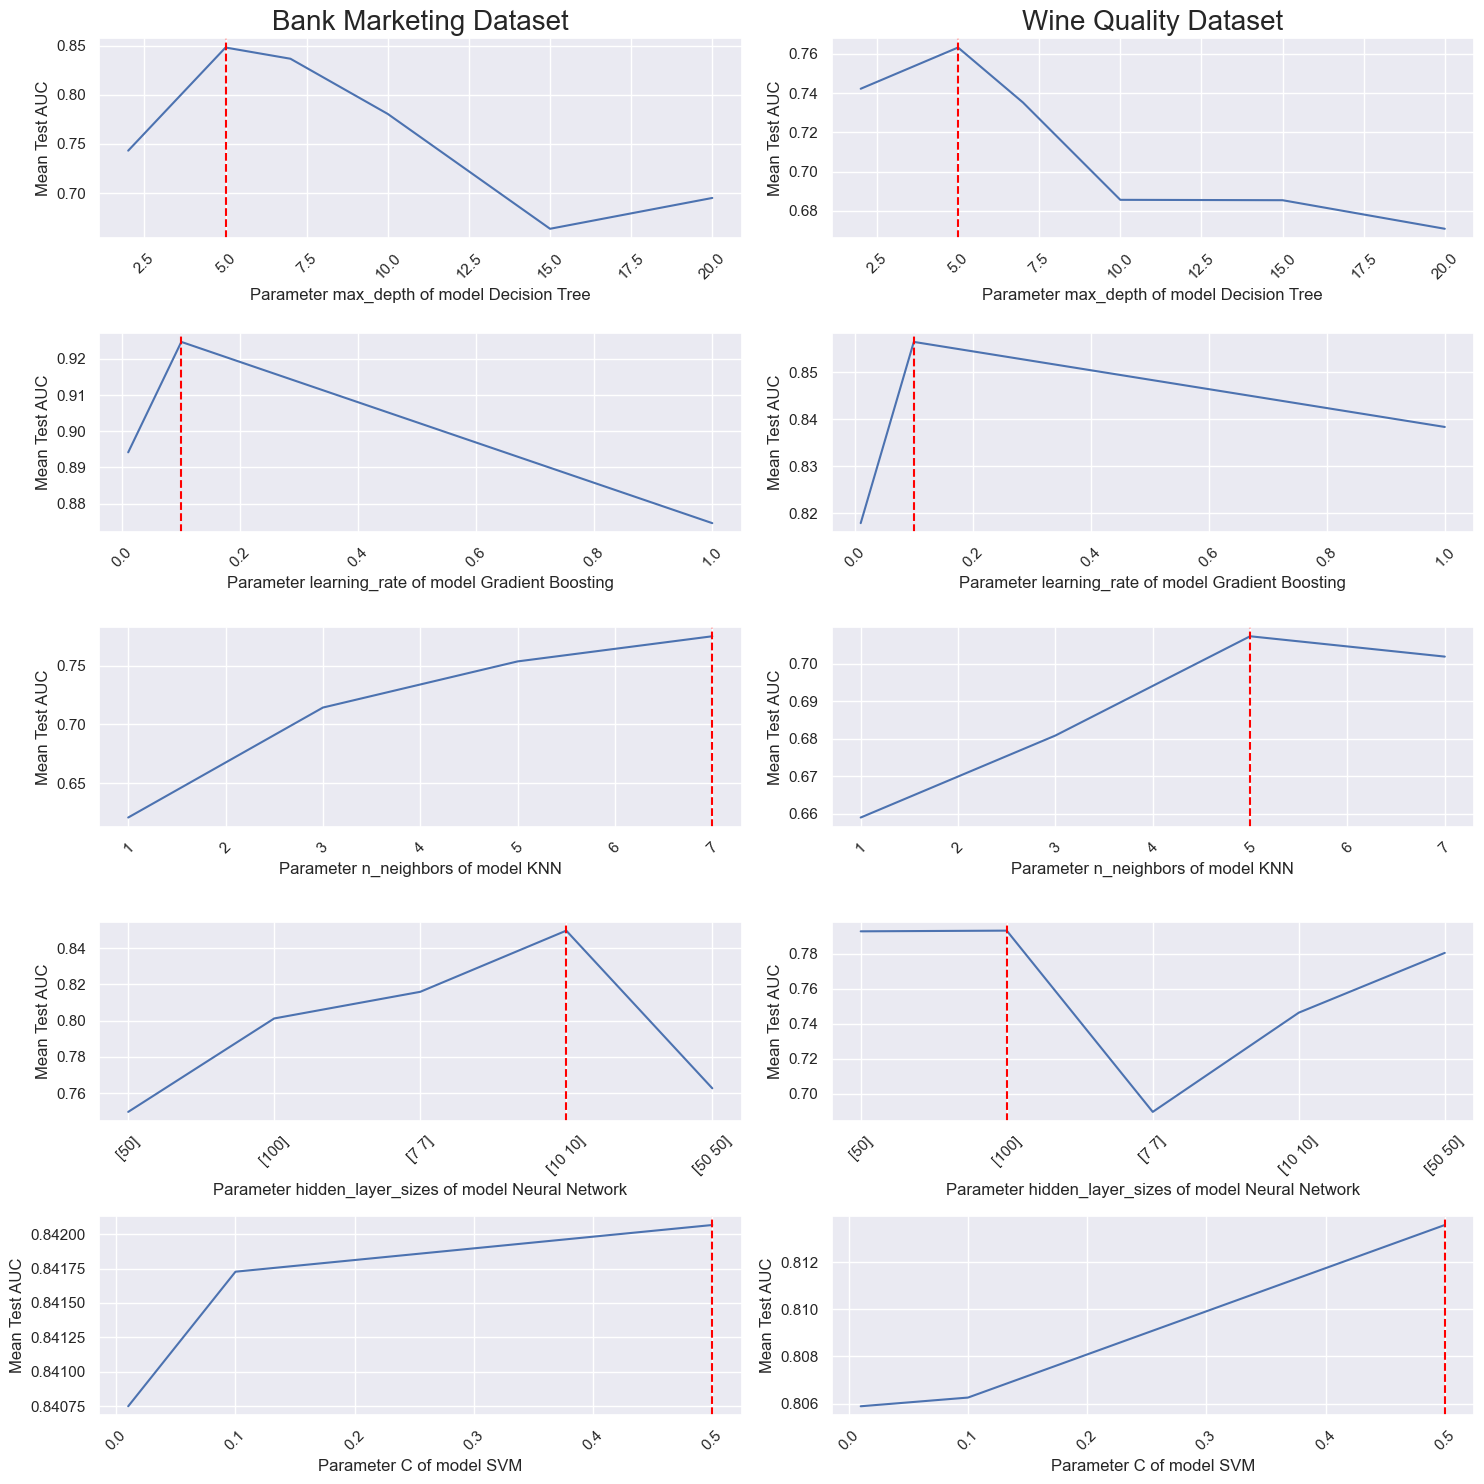

In [79]:
fig, ax = plt.subplots(5, 2, figsize=(15, 15))
params = {'Decision Tree': 'max_depth',
          'Gradient Boosting': 'learning_rate',
          'KNN': 'n_neighbors',
          'Neural Network': 'hidden_layer_sizes',
          'SVM': 'C'}

# plot AUC vs hyperparameters for each model
for i, dataset in enumerate(['bank', 'wine']):
    ax[0, i].set_title(titles[i])
    ax[0, i].title.set_fontsize(20)
    for j, model in enumerate(params.keys()):
        df_cvs_model = df_cvs_[(df_cvs['dataset'] == dataset) & (df_cvs['model'] == model)]
        df_cvs_model[params[model]] = df_cvs_model['params'].map(lambda x: x[params[model]])
        if model == 'Neural Network':
            df_cvs_model['hidden_layer_sizes'] = df_cvs_model['hidden_layer_sizes'].astype('str')
            df_cvs_model['alpha'] = df_cvs_model['params'].map(lambda x: x['alpha'])
            if dataset == 'bank':
                df_cvs_model = df_cvs_model[df_cvs_model['alpha'] == 0.1]
            elif dataset == 'wine':
                df_cvs_model = df_cvs_model[df_cvs_model['alpha'] == 0.001]
        elif model == 'Gradient Boosting':
            df_cvs_model['max_depth'] = df_cvs_model['params'].map(lambda x: x['max_depth'])
            if dataset == 'bank':
                df_cvs_model = df_cvs_model[df_cvs_model['max_depth'] == 5]
            elif dataset == 'wine':
                df_cvs_model = df_cvs_model[df_cvs_model['max_depth'] == 7]
        elif model == 'SVM':
            df_cvs_model['kernel'] = df_cvs_model['params'].map(lambda x: x['kernel'])
            df_cvs_model = df_cvs_model[df_cvs_model['kernel'] == 'rbf']
        sns.lineplot(x=params[model], y='mean_test_score', 
                     data=df_cvs_model, ax=ax[j, i])
        ax[j, i].set_xlabel(f"Parameter {params[model]} of model {model}")
        ax[j, i].set_ylabel('Mean Test AUC')
        best_param = df_cvs_model[df_cvs_model['mean_test_score'] == df_cvs_model['mean_test_score'].max()][params[model]].values[0]
        ax[j, i].axvline(best_param, color='red', linestyle='--')
        
        ax[j, i].set_xticklabels(ax[j, i].get_xticklabels(), rotation=45)

plt.tight_layout()
plt.savefig('models_hyperparams.png', dpi=300)